In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

# Create output directory
os.makedirs('figures_clustering', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ Libraries imported successfully')
print('📁 Clustering figures will be saved to: figures_clustering/')

✅ Libraries imported successfully
📁 Clustering figures will be saved to: figures_clustering/


## 1. Load and Prepare Data

In [15]:
# Load cleaned datasets (normal cleaned, not standardized or normalized)
economic_df = pd.read_csv('data/cleaned/clean_economic_indicators_cleaned.csv')
resources_df = pd.read_csv('data/cleaned/resources_human_capital_cleaned.csv')

print(f'📊 Economic Indicators Dataset: {economic_df.shape}')
print(f'📊 Resources & Human Capital Dataset: {resources_df.shape}')

# Separate country names from features
economic_countries = economic_df['Country'].values
economic_features = economic_df.drop('Country', axis=1)

resources_countries = resources_df['Country'].values
resources_features = resources_df.drop('Country', axis=1)

print(f'\n🌍 Countries in analysis: {len(economic_countries)}')
print(f'📈 Economic features: {economic_features.shape[1]}')
print(f'📈 Resources features: {resources_features.shape[1]}')

# Standardize features for clustering (required for distance-based algorithms)
scaler_econ = StandardScaler()
economic_features_scaled = scaler_econ.fit_transform(economic_features)

scaler_res = StandardScaler()
resources_features_scaled = scaler_res.fit_transform(resources_features)

print(f'\n✅ Features standardized for clustering')

# Find Algeria's index
algeria_idx_econ = np.where(np.char.lower(economic_countries.astype(str)) == 'algeria')[0]
algeria_idx_res = np.where(np.char.lower(resources_countries.astype(str)) == 'algeria')[0]

if len(algeria_idx_econ) > 0:
    print(f'\n🇩🇿 Algeria found at index {algeria_idx_econ[0]} in economic dataset')
if len(algeria_idx_res) > 0:
    print(f'🇩🇿 Algeria found at index {algeria_idx_res[0]} in resources dataset')

📊 Economic Indicators Dataset: (263, 66)
📊 Resources & Human Capital Dataset: (229, 86)

🌍 Countries in analysis: 263
📈 Economic features: 65
📈 Resources features: 85

✅ Features standardized for clustering

🇩🇿 Algeria found at index 2 in economic dataset
🇩🇿 Algeria found at index 2 in resources dataset


## 2. Dimensionality Reduction with PCA

Apply PCA to visualize high-dimensional data in 2D space and understand variance structure.

📊 PCA Variance Explained:

Economic Indicators:
   PC1: 14.32%
   PC2: 13.84%
   Total: 28.16%

Resources & Human Capital:
   PC1: 19.11%
   PC2: 18.57%
   Total: 37.68%

💾 Saved: figures_clustering/pca_visualization.png

💾 Saved: figures_clustering/pca_visualization.png


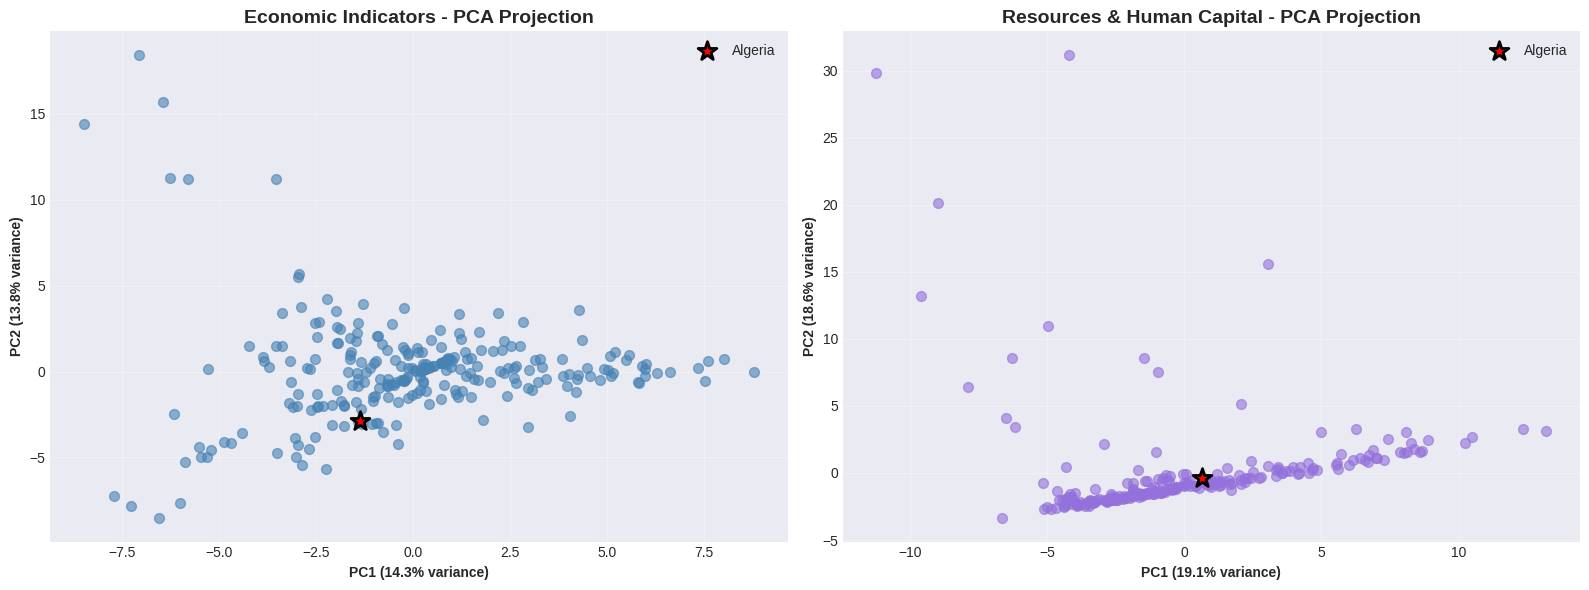

In [16]:
# Apply PCA for visualization using scaled features
pca_econ = PCA(n_components=2)
economic_pca = pca_econ.fit_transform(economic_features_scaled)

pca_res = PCA(n_components=2)
resources_pca = pca_res.fit_transform(resources_features_scaled)

print('📊 PCA Variance Explained:')
print(f'\nEconomic Indicators:')
print(f'   PC1: {pca_econ.explained_variance_ratio_[0]*100:.2f}%')
print(f'   PC2: {pca_econ.explained_variance_ratio_[1]*100:.2f}%')
print(f'   Total: {sum(pca_econ.explained_variance_ratio_)*100:.2f}%')

print(f'\nResources & Human Capital:')
print(f'   PC1: {pca_res.explained_variance_ratio_[0]*100:.2f}%')
print(f'   PC2: {pca_res.explained_variance_ratio_[1]*100:.2f}%')
print(f'   Total: {sum(pca_res.explained_variance_ratio_)*100:.2f}%')

# Visualize PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Economic dataset PCA
ax1.scatter(economic_pca[:, 0], economic_pca[:, 1], alpha=0.6, s=50, c='steelblue')
if len(algeria_idx_econ) > 0:
    ax1.scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                c='red', s=200, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
ax1.set_xlabel(f'PC1 ({pca_econ.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_econ.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
ax1.set_title('Economic Indicators - PCA Projection', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Resources dataset PCA
ax2.scatter(resources_pca[:, 0], resources_pca[:, 1], alpha=0.6, s=50, c='mediumpurple')
if len(algeria_idx_res) > 0:
    ax2.scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                c='red', s=200, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
ax2.set_xlabel(f'PC1 ({pca_res.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_res.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
ax2.set_title('Resources & Human Capital - PCA Projection', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures_clustering/pca_visualization.png', dpi=300, bbox_inches='tight')
print('\n💾 Saved: figures_clustering/pca_visualization.png')
plt.show()

## 3. K-Means Clustering

### 3.1 Elbow Method - Finding Optimal K

🔍 Testing K-Means with different k values...
   k=2: Economic Silhouette=0.506, Resources Silhouette=0.570
   k=2: Economic Silhouette=0.506, Resources Silhouette=0.570
   k=3: Economic Silhouette=0.175, Resources Silhouette=0.216
   k=3: Economic Silhouette=0.175, Resources Silhouette=0.216
   k=4: Economic Silhouette=0.175, Resources Silhouette=0.110
   k=4: Economic Silhouette=0.175, Resources Silhouette=0.110
   k=5: Economic Silhouette=0.129, Resources Silhouette=0.115
   k=5: Economic Silhouette=0.129, Resources Silhouette=0.115
   k=6: Economic Silhouette=0.113, Resources Silhouette=0.111
   k=6: Economic Silhouette=0.113, Resources Silhouette=0.111
   k=7: Economic Silhouette=0.128, Resources Silhouette=0.171
   k=7: Economic Silhouette=0.128, Resources Silhouette=0.171
   k=8: Economic Silhouette=0.112, Resources Silhouette=0.103
   k=8: Economic Silhouette=0.112, Resources Silhouette=0.103
   k=9: Economic Silhouette=0.141, Resources Silhouette=0.096
   k=9: Economic Silhouet

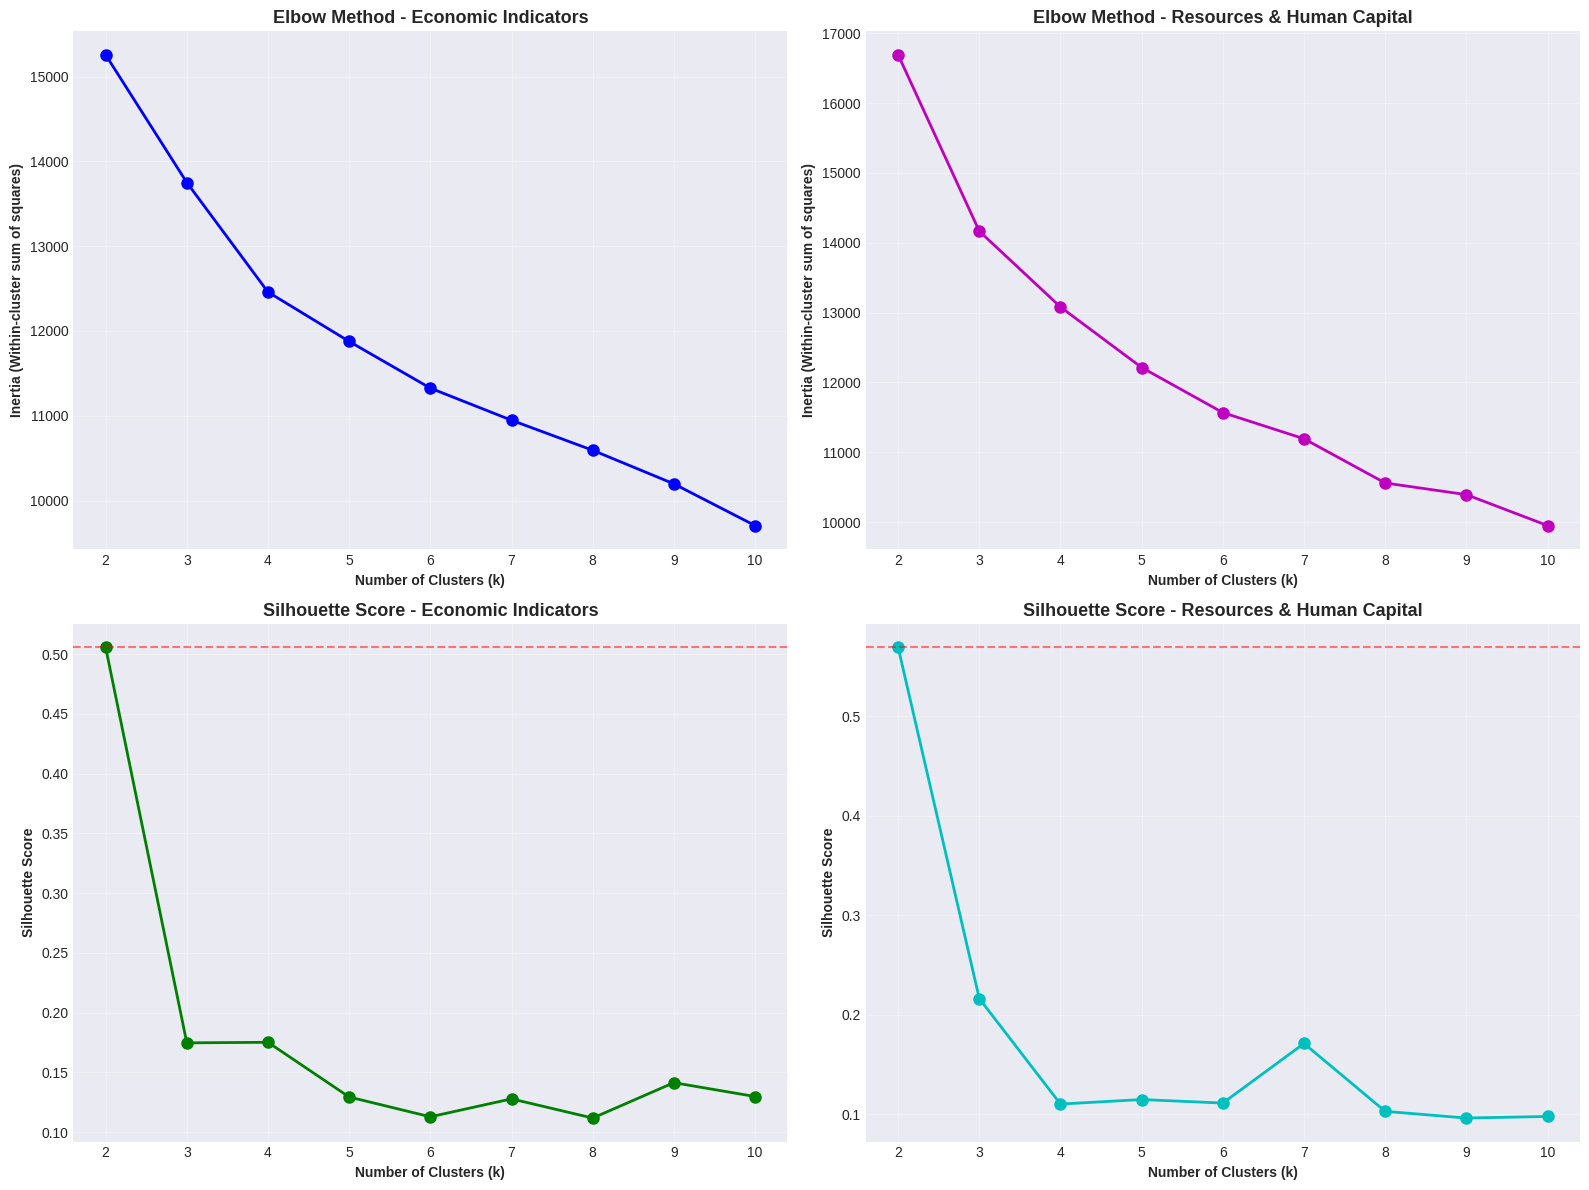


✅ Optimal k (highest silhouette):
   Economic dataset: k=2 (silhouette=0.506)
   Resources dataset: k=2 (silhouette=0.570)


In [17]:
# Test different k values using scaled features
k_range = range(2, 11)
inertias_econ = []
inertias_res = []
silhouette_econ = []
silhouette_res = []

print('🔍 Testing K-Means with different k values...')

for k in k_range:
    # Economic dataset
    kmeans_econ = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_econ = kmeans_econ.fit_predict(economic_features_scaled)
    inertias_econ.append(kmeans_econ.inertia_)
    silhouette_econ.append(silhouette_score(economic_features_scaled, labels_econ))
    
    # Resources dataset
    kmeans_res = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_res = kmeans_res.fit_predict(resources_features_scaled)
    inertias_res.append(kmeans_res.inertia_)
    silhouette_res.append(silhouette_score(resources_features_scaled, labels_res))
    
    print(f'   k={k}: Economic Silhouette={silhouette_econ[-1]:.3f}, Resources Silhouette={silhouette_res[-1]:.3f}')

# Plot elbow curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Elbow plot - Economic
axes[0, 0].plot(k_range, inertias_econ, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontweight='bold')
axes[0, 0].set_ylabel('Inertia (Within-cluster sum of squares)', fontweight='bold')
axes[0, 0].set_title('Elbow Method - Economic Indicators', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(k_range)

# Elbow plot - Resources
axes[0, 1].plot(k_range, inertias_res, 'mo-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontweight='bold')
axes[0, 1].set_ylabel('Inertia (Within-cluster sum of squares)', fontweight='bold')
axes[0, 1].set_title('Elbow Method - Resources & Human Capital', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(k_range)

# Silhouette plot - Economic
axes[1, 0].plot(k_range, silhouette_econ, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontweight='bold')
axes[1, 0].set_ylabel('Silhouette Score', fontweight='bold')
axes[1, 0].set_title('Silhouette Score - Economic Indicators', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(k_range)
axes[1, 0].axhline(y=max(silhouette_econ), color='r', linestyle='--', alpha=0.5)

# Silhouette plot - Resources
axes[1, 1].plot(k_range, silhouette_res, 'co-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontweight='bold')
axes[1, 1].set_ylabel('Silhouette Score', fontweight='bold')
axes[1, 1].set_title('Silhouette Score - Resources & Human Capital', fontsize=13, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(k_range)
axes[1, 1].axhline(y=max(silhouette_res), color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures_clustering/kmeans_elbow_silhouette.png', dpi=300, bbox_inches='tight')
print('\n💾 Saved: figures_clustering/kmeans_elbow_silhouette.png')
plt.show()

# Find optimal k
optimal_k_econ = k_range[np.argmax(silhouette_econ)]
optimal_k_res = k_range[np.argmax(silhouette_res)]

print(f'\n✅ Optimal k (highest silhouette):')
print(f'   Economic dataset: k={optimal_k_econ} (silhouette={max(silhouette_econ):.3f})')
print(f'   Resources dataset: k={optimal_k_res} (silhouette={max(silhouette_res):.3f})')

### 3.2 K-Means with Optimal K

💾 Saved: figures_clustering/kmeans_clusters.png


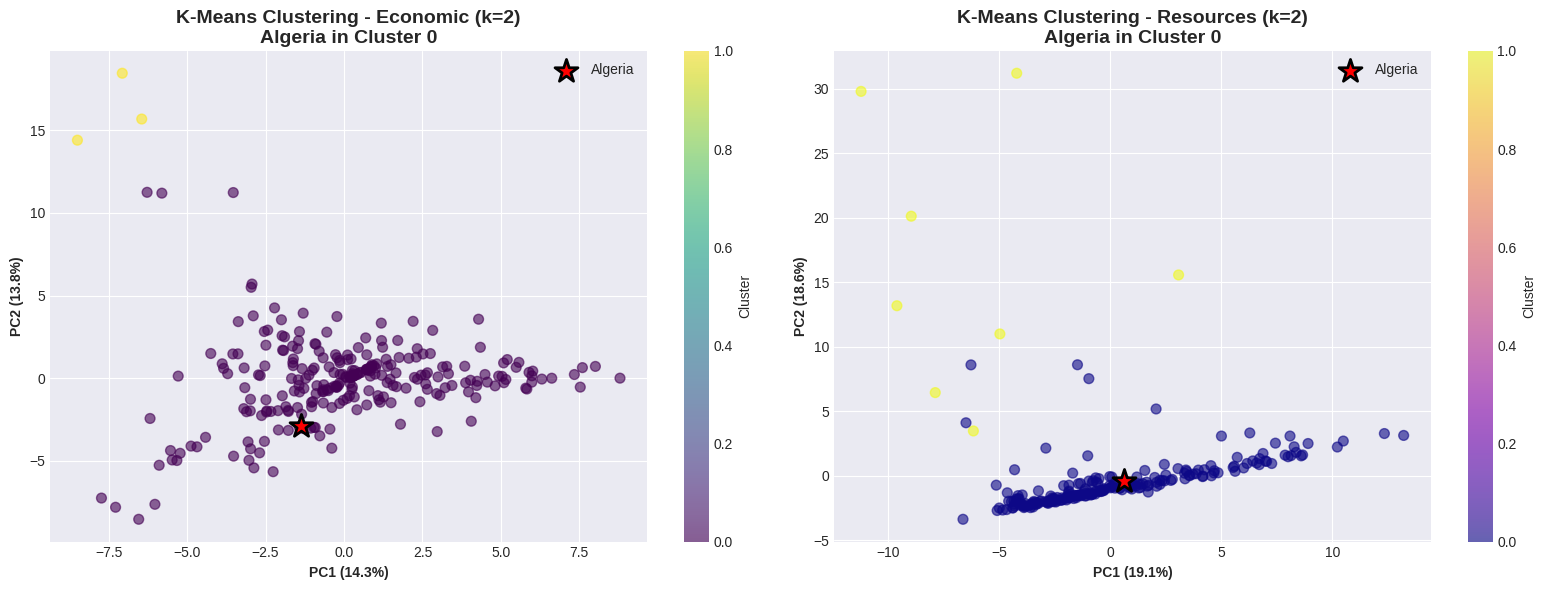


🇩🇿 Algeria Economic Cluster Analysis:
   Cluster 0 has 260 countries
   Countries in Algeria's cluster: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Arab World', 'Argentina', 'Armenia']
   ... and 250 more

🇩🇿 Algeria Resources Cluster Analysis:
   Cluster 0 has 221 countries
   Countries in Algeria's cluster: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba']
   ... and 211 more


In [18]:
# Apply K-Means with optimal k
kmeans_econ_optimal = KMeans(n_clusters=optimal_k_econ, random_state=42, n_init=10)
economic_kmeans_labels = kmeans_econ_optimal.fit_predict(economic_features)

kmeans_res_optimal = KMeans(n_clusters=optimal_k_res, random_state=42, n_init=10)
resources_kmeans_labels = kmeans_res_optimal.fit_predict(resources_features)

# Visualize K-Means clusters in PCA space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Economic clusters
scatter1 = ax1.scatter(economic_pca[:, 0], economic_pca[:, 1], 
                       c=economic_kmeans_labels, cmap='viridis', alpha=0.6, s=50)
if len(algeria_idx_econ) > 0:
    ax1.scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
    algeria_cluster_econ = economic_kmeans_labels[algeria_idx_econ[0]]
    ax1.set_title(f'K-Means Clustering - Economic (k={optimal_k_econ})\nAlgeria in Cluster {algeria_cluster_econ}', 
                  fontsize=14, fontweight='bold')
else:
    ax1.set_title(f'K-Means Clustering - Economic (k={optimal_k_econ})', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_econ.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_econ.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Resources clusters
scatter2 = ax2.scatter(resources_pca[:, 0], resources_pca[:, 1], 
                       c=resources_kmeans_labels, cmap='plasma', alpha=0.6, s=50)
if len(algeria_idx_res) > 0:
    ax2.scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
    algeria_cluster_res = resources_kmeans_labels[algeria_idx_res[0]]
    ax2.set_title(f'K-Means Clustering - Resources (k={optimal_k_res})\nAlgeria in Cluster {algeria_cluster_res}', 
                  fontsize=14, fontweight='bold')
else:
    ax2.set_title(f'K-Means Clustering - Resources (k={optimal_k_res})', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca_res.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_res.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.savefig('figures_clustering/kmeans_clusters.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures_clustering/kmeans_clusters.png')
plt.show()

# Analyze Algeria's cluster
if len(algeria_idx_econ) > 0:
    print(f'\n🇩🇿 Algeria Economic Cluster Analysis:')
    cluster_members_econ = economic_countries[economic_kmeans_labels == algeria_cluster_econ]
    print(f'   Cluster {algeria_cluster_econ} has {len(cluster_members_econ)} countries')
    print(f'   Countries in Algeria\'s cluster: {list(cluster_members_econ[:10])}')
    if len(cluster_members_econ) > 10:
        print(f'   ... and {len(cluster_members_econ) - 10} more')

if len(algeria_idx_res) > 0:
    print(f'\n🇩🇿 Algeria Resources Cluster Analysis:')
    cluster_members_res = resources_countries[resources_kmeans_labels == algeria_cluster_res]
    print(f'   Cluster {algeria_cluster_res} has {len(cluster_members_res)} countries')
    print(f'   Countries in Algeria\'s cluster: {list(cluster_members_res[:10])}')
    if len(cluster_members_res) > 10:
        print(f'   ... and {len(cluster_members_res) - 10} more')

## 4. Hierarchical Clustering

### 4.1 Dendrogram Analysis

🔍 Computing hierarchical clustering...
💾 Saved: figures_clustering/hierarchical_dendrogram.png
💾 Saved: figures_clustering/hierarchical_dendrogram.png


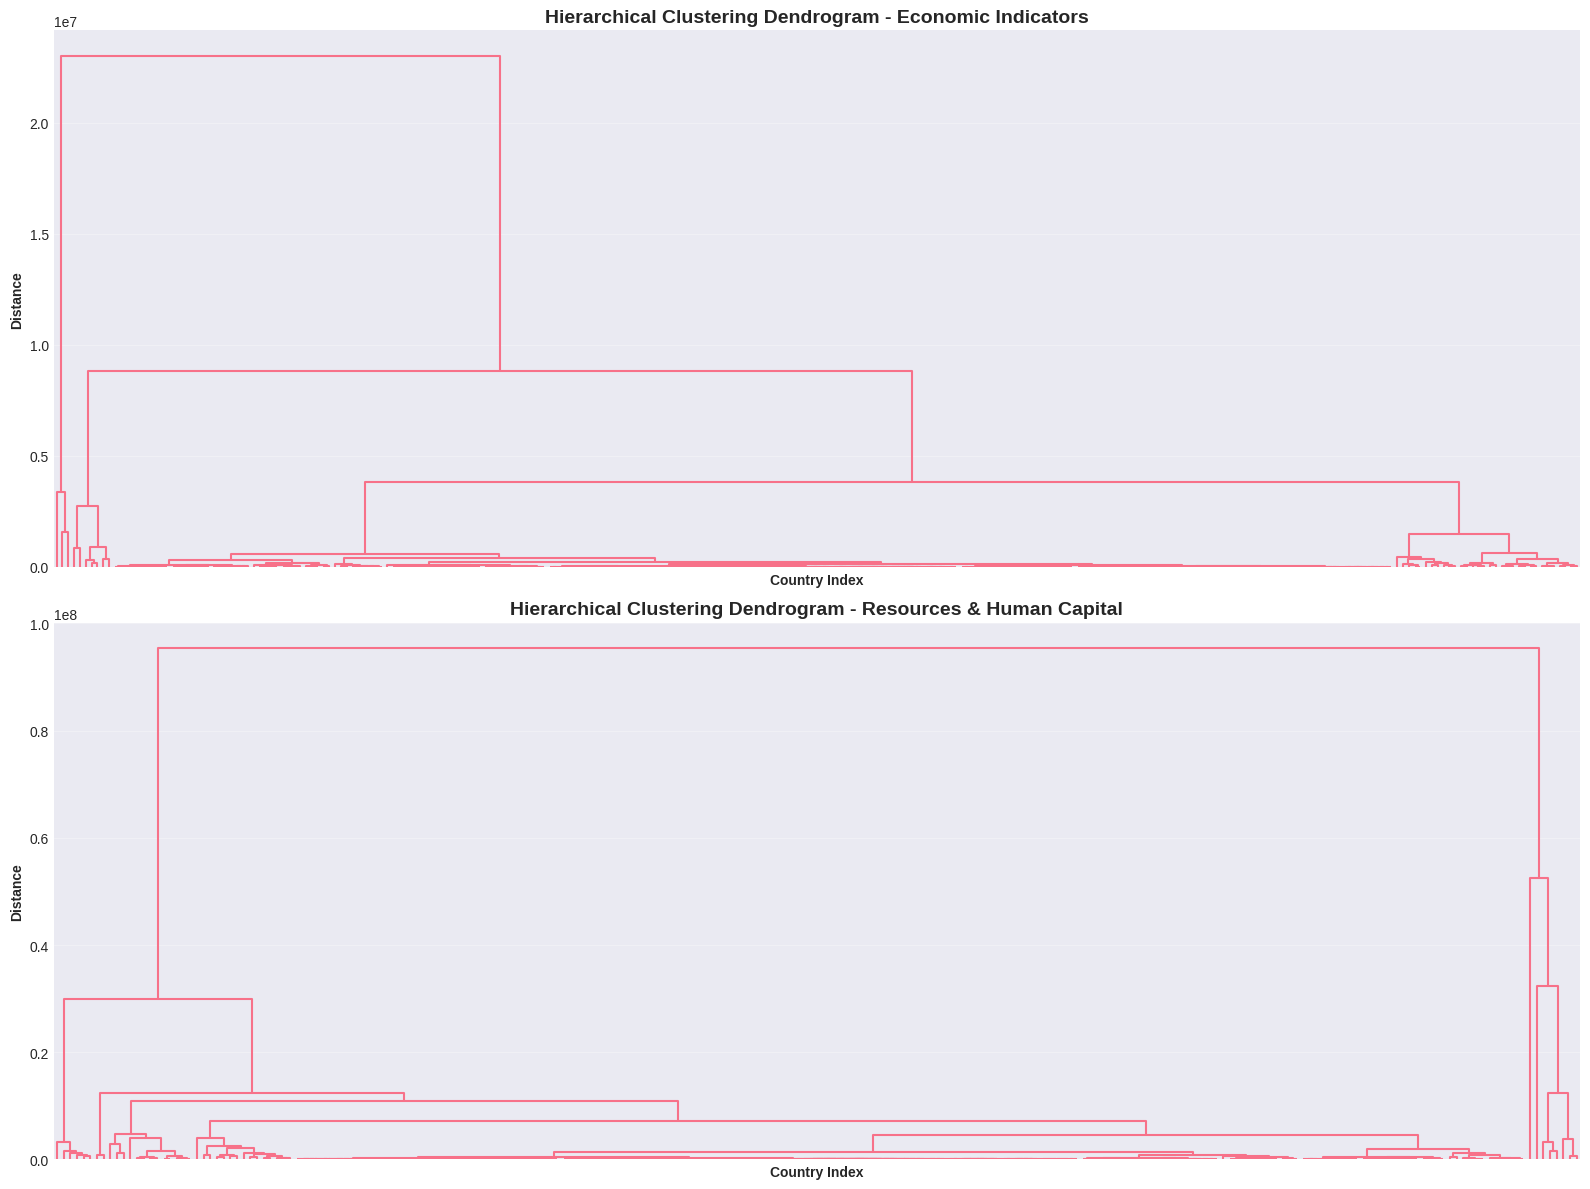

In [19]:
# Compute linkage matrices
print('🔍 Computing hierarchical clustering...')
linkage_econ = linkage(economic_features, method='ward')
linkage_res = linkage(resources_features, method='ward')

# Plot dendrograms
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Economic dendrogram
dendrogram(linkage_econ, ax=ax1, no_labels=True, color_threshold=0)
ax1.set_title('Hierarchical Clustering Dendrogram - Economic Indicators', fontsize=14, fontweight='bold')
ax1.set_xlabel('Country Index', fontweight='bold')
ax1.set_ylabel('Distance', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Resources dendrogram
dendrogram(linkage_res, ax=ax2, no_labels=True, color_threshold=0)
ax2.set_title('Hierarchical Clustering Dendrogram - Resources & Human Capital', fontsize=14, fontweight='bold')
ax2.set_xlabel('Country Index', fontweight='bold')
ax2.set_ylabel('Distance', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures_clustering/hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures_clustering/hierarchical_dendrogram.png')
plt.show()

### 4.2 Hierarchical Clustering with Optimal Clusters

💾 Saved: figures_clustering/hierarchical_clusters.png


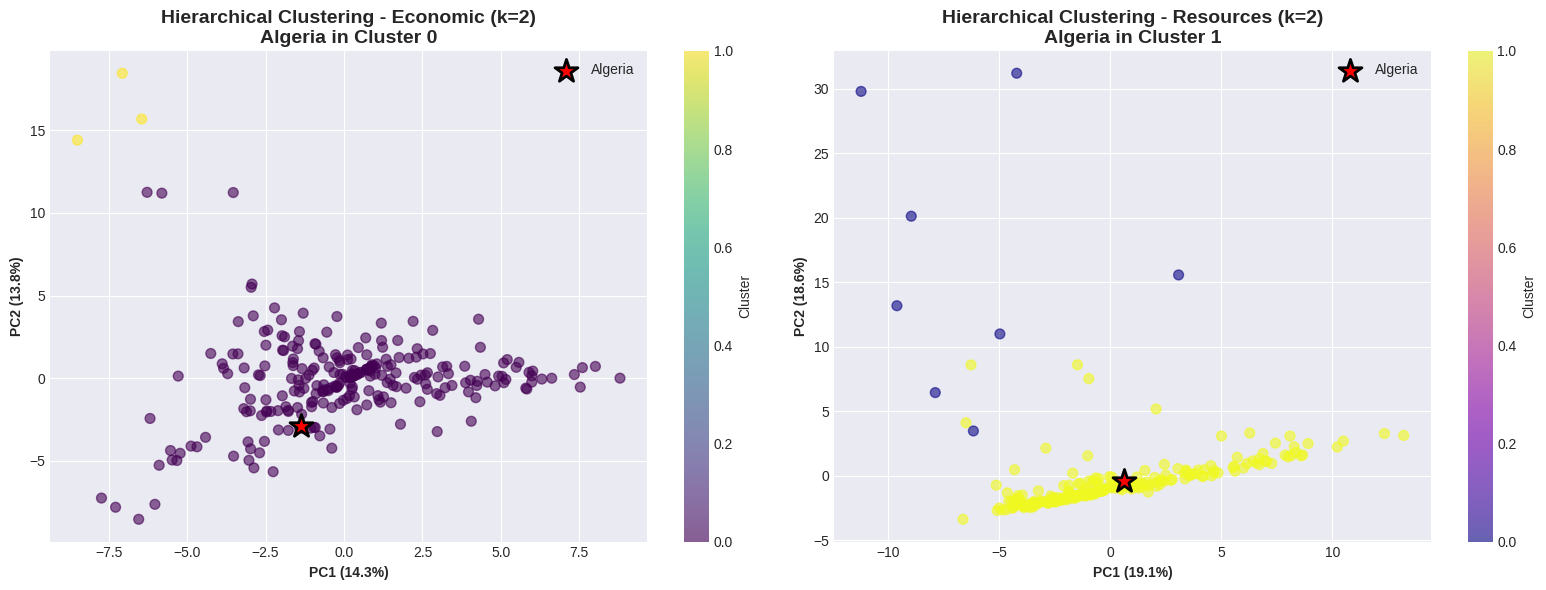

In [20]:
# Apply hierarchical clustering with same k as K-Means for comparison
hierarchical_econ = AgglomerativeClustering(n_clusters=optimal_k_econ, linkage='ward')
economic_hierarchical_labels = hierarchical_econ.fit_predict(economic_features)

hierarchical_res = AgglomerativeClustering(n_clusters=optimal_k_res, linkage='ward')
resources_hierarchical_labels = hierarchical_res.fit_predict(resources_features)

# Visualize hierarchical clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Economic clusters
scatter1 = ax1.scatter(economic_pca[:, 0], economic_pca[:, 1], 
                       c=economic_hierarchical_labels, cmap='viridis', alpha=0.6, s=50)
if len(algeria_idx_econ) > 0:
    ax1.scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
    algeria_cluster_hier_econ = economic_hierarchical_labels[algeria_idx_econ[0]]
    ax1.set_title(f'Hierarchical Clustering - Economic (k={optimal_k_econ})\nAlgeria in Cluster {algeria_cluster_hier_econ}', 
                  fontsize=14, fontweight='bold')
else:
    ax1.set_title(f'Hierarchical Clustering - Economic (k={optimal_k_econ})', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_econ.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_econ.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Resources clusters
scatter2 = ax2.scatter(resources_pca[:, 0], resources_pca[:, 1], 
                       c=resources_hierarchical_labels, cmap='plasma', alpha=0.6, s=50)
if len(algeria_idx_res) > 0:
    ax2.scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
    algeria_cluster_hier_res = resources_hierarchical_labels[algeria_idx_res[0]]
    ax2.set_title(f'Hierarchical Clustering - Resources (k={optimal_k_res})\nAlgeria in Cluster {algeria_cluster_hier_res}', 
                  fontsize=14, fontweight='bold')
else:
    ax2.set_title(f'Hierarchical Clustering - Resources (k={optimal_k_res})', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca_res.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_res.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.savefig('figures_clustering/hierarchical_clusters.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures_clustering/hierarchical_clusters.png')
plt.show()

## 5. DBSCAN Clustering

Density-based clustering to identify core groups and outliers.

In [21]:
# Test different eps values for DBSCAN
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples = 5

print(f'🔍 Testing DBSCAN with different eps values (min_samples={min_samples})...')

best_eps_econ = None
best_eps_res = None
best_score_econ = -1
best_score_res = -1

for eps in eps_values:
    # Economic
    dbscan_econ = DBSCAN(eps=eps, min_samples=min_samples)
    labels_econ = dbscan_econ.fit_predict(economic_features)
    n_clusters_econ = len(set(labels_econ)) - (1 if -1 in labels_econ else 0)
    n_noise_econ = list(labels_econ).count(-1)
    
    # Resources
    dbscan_res = DBSCAN(eps=eps, min_samples=min_samples)
    labels_res = dbscan_res.fit_predict(resources_features)
    n_clusters_res = len(set(labels_res)) - (1 if -1 in labels_res else 0)
    n_noise_res = list(labels_res).count(-1)
    
    print(f'   eps={eps}:')
    print(f'      Economic: {n_clusters_econ} clusters, {n_noise_econ} noise points')
    print(f'      Resources: {n_clusters_res} clusters, {n_noise_res} noise points')
    
    # Choose best eps (most clusters with reasonable noise)
    if n_clusters_econ > 1 and n_noise_econ < len(labels_econ) * 0.3:
        score_econ = n_clusters_econ - (n_noise_econ / len(labels_econ))
        if score_econ > best_score_econ:
            best_score_econ = score_econ
            best_eps_econ = eps
    
    if n_clusters_res > 1 and n_noise_res < len(labels_res) * 0.3:
        score_res = n_clusters_res - (n_noise_res / len(labels_res))
        if score_res > best_score_res:
            best_score_res = score_res
            best_eps_res = eps

# Use default eps if no good value found
if best_eps_econ is None:
    best_eps_econ = 2.0
if best_eps_res is None:
    best_eps_res = 2.0

print(f'\n✅ Selected eps for Economic: {best_eps_econ}')
print(f'✅ Selected eps for Resources: {best_eps_res}')

🔍 Testing DBSCAN with different eps values (min_samples=5)...
   eps=0.5:
      Economic: 0 clusters, 263 noise points
      Resources: 0 clusters, 229 noise points
   eps=1.0:
      Economic: 0 clusters, 263 noise points
      Resources: 0 clusters, 229 noise points
   eps=1.5:
      Economic: 0 clusters, 263 noise points
      Resources: 0 clusters, 229 noise points
   eps=2.0:
      Economic: 0 clusters, 263 noise points
      Resources: 0 clusters, 229 noise points
   eps=2.5:
      Economic: 0 clusters, 263 noise points
      Resources: 0 clusters, 229 noise points
   eps=3.0:
      Economic: 2 clusters, 250 noise points
      Resources: 0 clusters, 229 noise points

✅ Selected eps for Economic: 2.0
✅ Selected eps for Resources: 2.0


💾 Saved: figures_clustering/dbscan_clusters.png


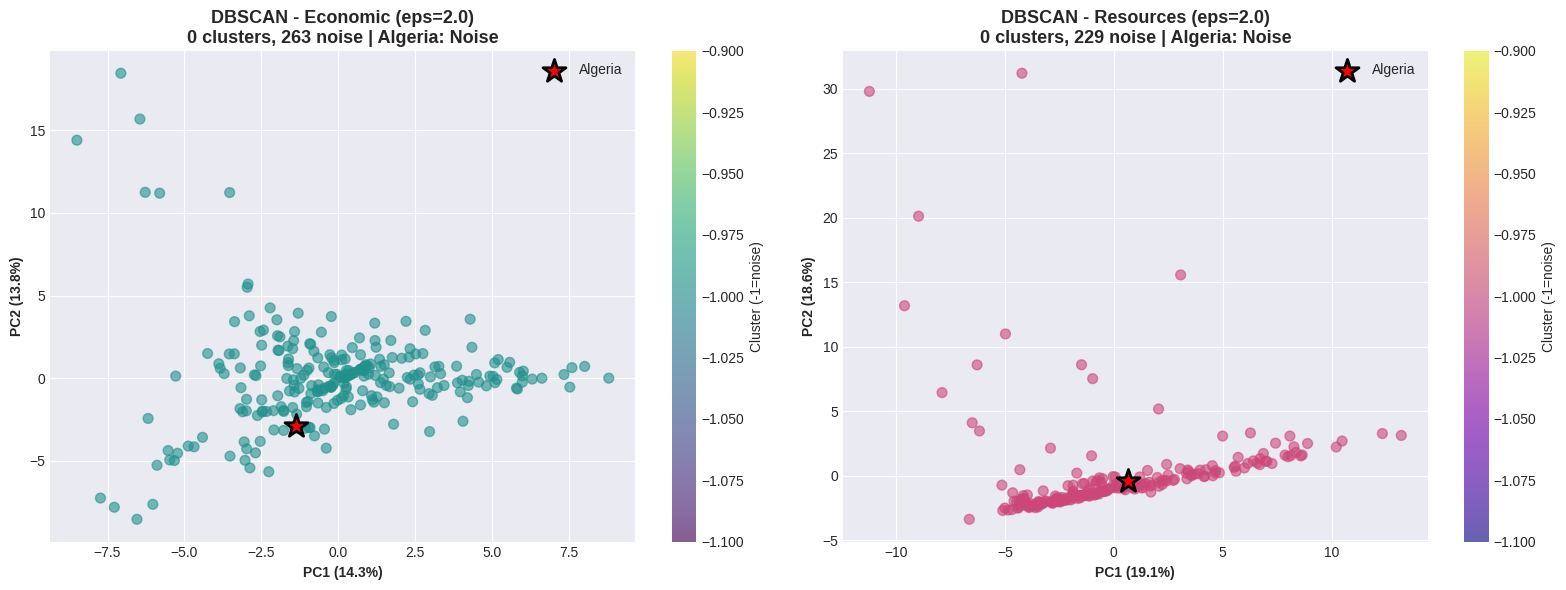

In [22]:
# Apply DBSCAN with selected eps
dbscan_econ_final = DBSCAN(eps=best_eps_econ, min_samples=min_samples)
economic_dbscan_labels = dbscan_econ_final.fit_predict(economic_features)

dbscan_res_final = DBSCAN(eps=best_eps_res, min_samples=min_samples)
resources_dbscan_labels = dbscan_res_final.fit_predict(resources_features)

n_clusters_econ_final = len(set(economic_dbscan_labels)) - (1 if -1 in economic_dbscan_labels else 0)
n_noise_econ_final = list(economic_dbscan_labels).count(-1)

n_clusters_res_final = len(set(resources_dbscan_labels)) - (1 if -1 in resources_dbscan_labels else 0)
n_noise_res_final = list(resources_dbscan_labels).count(-1)

# Visualize DBSCAN clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Economic clusters
scatter1 = ax1.scatter(economic_pca[:, 0], economic_pca[:, 1], 
                       c=economic_dbscan_labels, cmap='viridis', alpha=0.6, s=50)
if len(algeria_idx_econ) > 0:
    ax1.scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
    algeria_cluster_dbscan_econ = economic_dbscan_labels[algeria_idx_econ[0]]
    cluster_status = 'Noise' if algeria_cluster_dbscan_econ == -1 else f'Cluster {algeria_cluster_dbscan_econ}'
    ax1.set_title(f'DBSCAN - Economic (eps={best_eps_econ})\n{n_clusters_econ_final} clusters, {n_noise_econ_final} noise | Algeria: {cluster_status}', 
                  fontsize=13, fontweight='bold')
else:
    ax1.set_title(f'DBSCAN - Economic (eps={best_eps_econ})\n{n_clusters_econ_final} clusters, {n_noise_econ_final} noise points', 
                  fontsize=13, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_econ.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_econ.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Cluster (-1=noise)')

# Resources clusters
scatter2 = ax2.scatter(resources_pca[:, 0], resources_pca[:, 1], 
                       c=resources_dbscan_labels, cmap='plasma', alpha=0.6, s=50)
if len(algeria_idx_res) > 0:
    ax2.scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Algeria', zorder=5)
    algeria_cluster_dbscan_res = resources_dbscan_labels[algeria_idx_res[0]]
    cluster_status = 'Noise' if algeria_cluster_dbscan_res == -1 else f'Cluster {algeria_cluster_dbscan_res}'
    ax2.set_title(f'DBSCAN - Resources (eps={best_eps_res})\n{n_clusters_res_final} clusters, {n_noise_res_final} noise | Algeria: {cluster_status}', 
                  fontsize=13, fontweight='bold')
else:
    ax2.set_title(f'DBSCAN - Resources (eps={best_eps_res})\n{n_clusters_res_final} clusters, {n_noise_res_final} noise points', 
                  fontsize=13, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca_res.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_res.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Cluster (-1=noise)')

plt.tight_layout()
plt.savefig('figures_clustering/dbscan_clusters.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures_clustering/dbscan_clusters.png')
plt.show()

## 6. Clustering Comparison and Evaluation

In [23]:
# Calculate evaluation metrics for all algorithms
def evaluate_clustering(features, labels, algorithm_name):
    """Calculate clustering evaluation metrics"""
    # Remove noise points for DBSCAN
    mask = labels != -1
    if mask.sum() < 2:
        return {'algorithm': algorithm_name, 'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan}
    
    labels_clean = labels[mask]
    features_clean = features[mask]
    
    # Check if we have enough clusters
    n_clusters = len(set(labels_clean))
    if n_clusters < 2:
        return {'algorithm': algorithm_name, 'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan}
    
    silhouette = silhouette_score(features_clean, labels_clean)
    davies_bouldin = davies_bouldin_score(features_clean, labels_clean)
    calinski_harabasz = calinski_harabasz_score(features_clean, labels_clean)
    
    return {
        'algorithm': algorithm_name,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz
    }

# Evaluate all algorithms on both datasets
print('📊 CLUSTERING EVALUATION METRICS')
print('='*80)

print('\n🔹 Economic Indicators Dataset:')
print('-'*80)
metrics_econ = []
metrics_econ.append(evaluate_clustering(economic_features.values, economic_kmeans_labels, 'K-Means'))
metrics_econ.append(evaluate_clustering(economic_features.values, economic_hierarchical_labels, 'Hierarchical'))
metrics_econ.append(evaluate_clustering(economic_features.values, economic_dbscan_labels, 'DBSCAN'))

df_metrics_econ = pd.DataFrame(metrics_econ)
print(df_metrics_econ.to_string(index=False))

print('\n🔹 Resources & Human Capital Dataset:')
print('-'*80)
metrics_res = []
metrics_res.append(evaluate_clustering(resources_features.values, resources_kmeans_labels, 'K-Means'))
metrics_res.append(evaluate_clustering(resources_features.values, resources_hierarchical_labels, 'Hierarchical'))
metrics_res.append(evaluate_clustering(resources_features.values, resources_dbscan_labels, 'DBSCAN'))

df_metrics_res = pd.DataFrame(metrics_res)
print(df_metrics_res.to_string(index=False))

print('\n📌 Metric Interpretation:')
print('   • Silhouette Score: Higher is better (range: -1 to 1)')
print('   • Davies-Bouldin Index: Lower is better')
print('   • Calinski-Harabasz Score: Higher is better')

📊 CLUSTERING EVALUATION METRICS

🔹 Economic Indicators Dataset:
--------------------------------------------------------------------------------
   algorithm  silhouette  davies_bouldin  calinski_harabasz
     K-Means       0.966           0.162           1150.320
Hierarchical       0.966           0.162           1150.320
      DBSCAN         NaN             NaN                NaN

🔹 Resources & Human Capital Dataset:
--------------------------------------------------------------------------------
   algorithm  silhouette  davies_bouldin  calinski_harabasz
     K-Means       0.929           0.559            386.974
Hierarchical       0.929           0.559            386.974
      DBSCAN         NaN             NaN                NaN

📌 Metric Interpretation:
   • Silhouette Score: Higher is better (range: -1 to 1)
   • Davies-Bouldin Index: Lower is better
   • Calinski-Harabasz Score: Higher is better


💾 Saved: figures_clustering/clustering_comparison.png


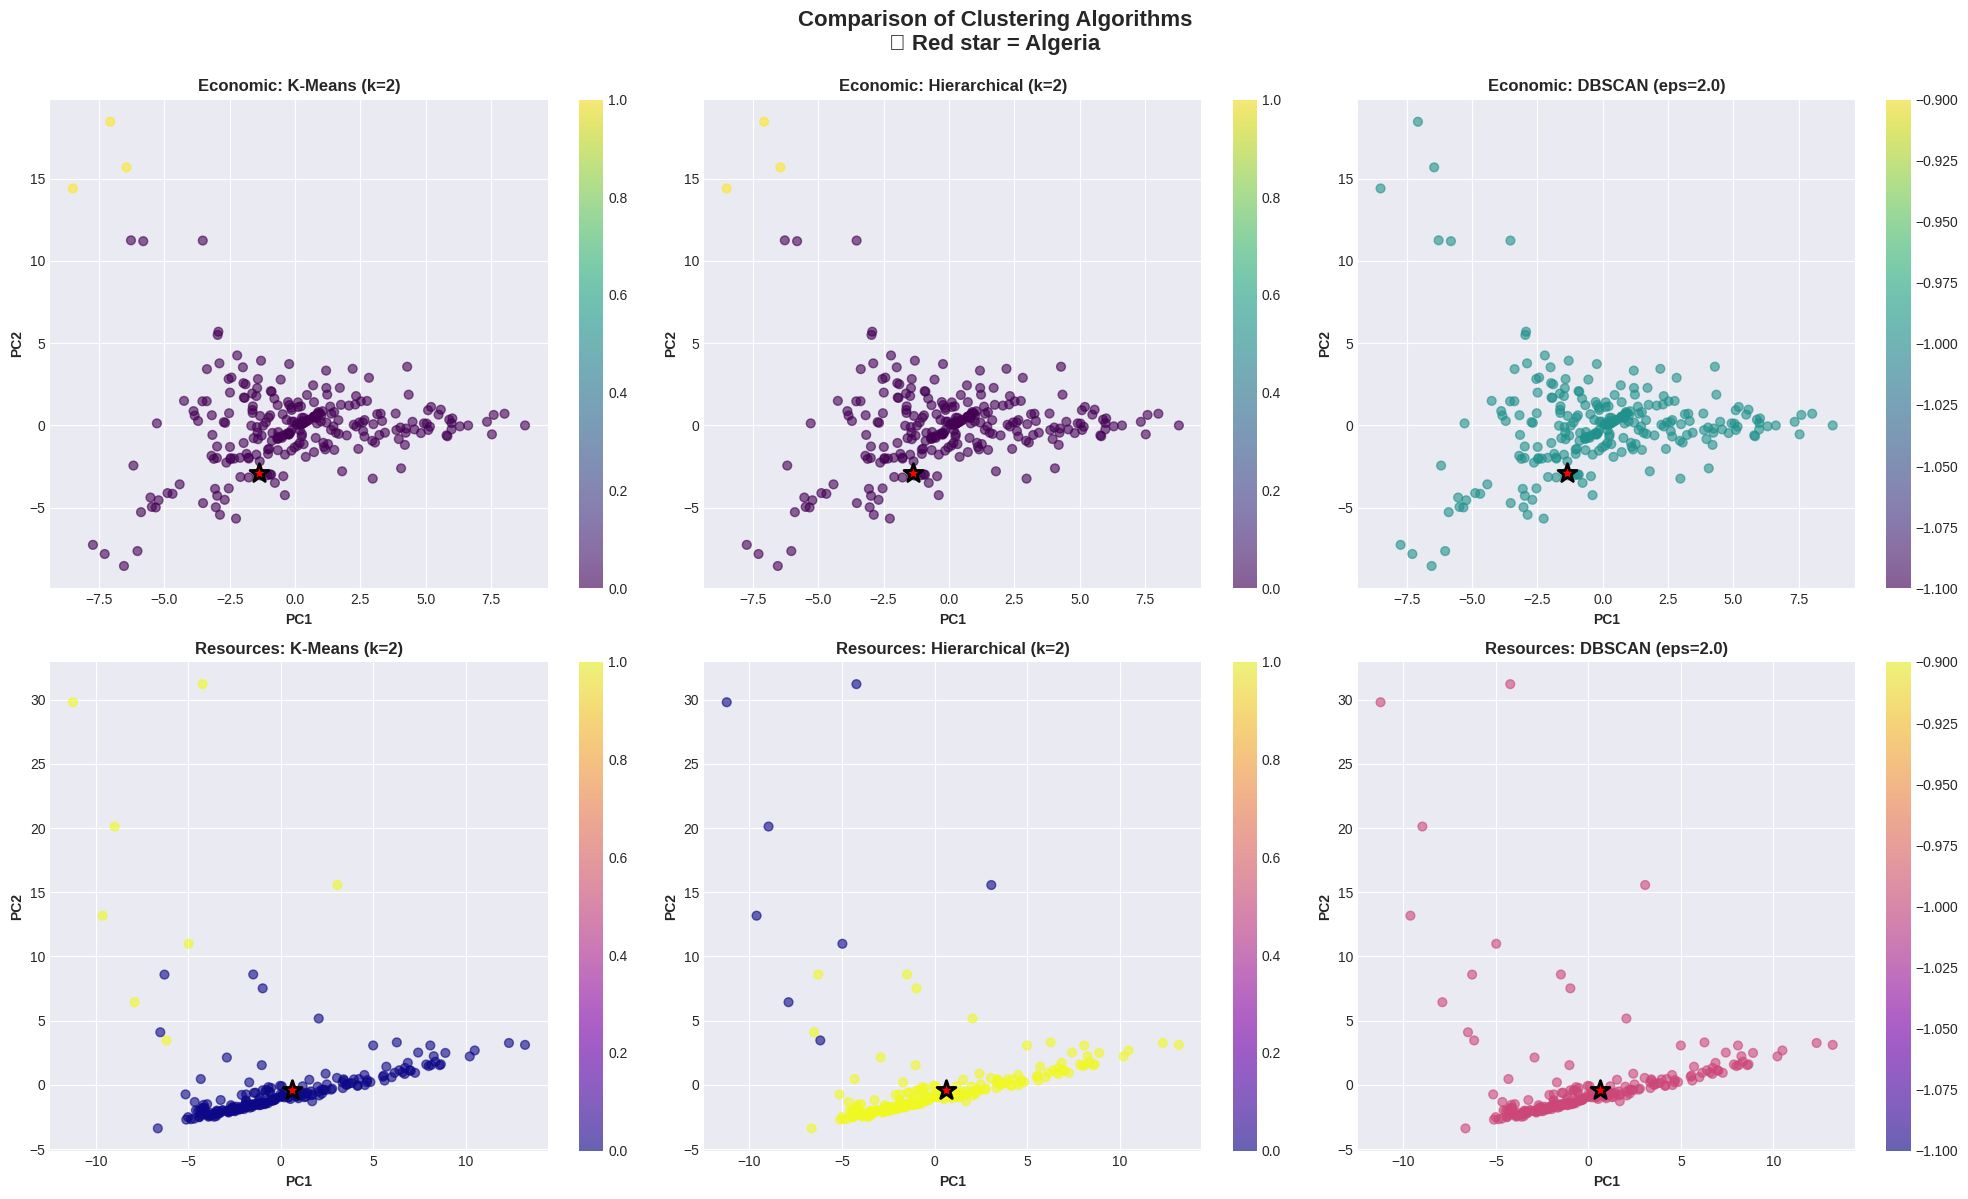

In [24]:
# Visualize comparison of all algorithms
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Economic - K-Means
scatter = axes[0, 0].scatter(economic_pca[:, 0], economic_pca[:, 1], c=economic_kmeans_labels, cmap='viridis', alpha=0.6, s=40)
if len(algeria_idx_econ) > 0:
    axes[0, 0].scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                       c='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
axes[0, 0].set_title(f'Economic: K-Means (k={optimal_k_econ})', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('PC1', fontweight='bold')
axes[0, 0].set_ylabel('PC2', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0])

# Economic - Hierarchical
scatter = axes[0, 1].scatter(economic_pca[:, 0], economic_pca[:, 1], c=economic_hierarchical_labels, cmap='viridis', alpha=0.6, s=40)
if len(algeria_idx_econ) > 0:
    axes[0, 1].scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                       c='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
axes[0, 1].set_title(f'Economic: Hierarchical (k={optimal_k_econ})', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('PC1', fontweight='bold')
axes[0, 1].set_ylabel('PC2', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 1])

# Economic - DBSCAN
scatter = axes[0, 2].scatter(economic_pca[:, 0], economic_pca[:, 1], c=economic_dbscan_labels, cmap='viridis', alpha=0.6, s=40)
if len(algeria_idx_econ) > 0:
    axes[0, 2].scatter(economic_pca[algeria_idx_econ, 0], economic_pca[algeria_idx_econ, 1], 
                       c='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
axes[0, 2].set_title(f'Economic: DBSCAN (eps={best_eps_econ})', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('PC1', fontweight='bold')
axes[0, 2].set_ylabel('PC2', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 2])

# Resources - K-Means
scatter = axes[1, 0].scatter(resources_pca[:, 0], resources_pca[:, 1], c=resources_kmeans_labels, cmap='plasma', alpha=0.6, s=40)
if len(algeria_idx_res) > 0:
    axes[1, 0].scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                       c='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
axes[1, 0].set_title(f'Resources: K-Means (k={optimal_k_res})', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('PC1', fontweight='bold')
axes[1, 0].set_ylabel('PC2', fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 0])

# Resources - Hierarchical
scatter = axes[1, 1].scatter(resources_pca[:, 0], resources_pca[:, 1], c=resources_hierarchical_labels, cmap='plasma', alpha=0.6, s=40)
if len(algeria_idx_res) > 0:
    axes[1, 1].scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                       c='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
axes[1, 1].set_title(f'Resources: Hierarchical (k={optimal_k_res})', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('PC1', fontweight='bold')
axes[1, 1].set_ylabel('PC2', fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 1])

# Resources - DBSCAN
scatter = axes[1, 2].scatter(resources_pca[:, 0], resources_pca[:, 1], c=resources_dbscan_labels, cmap='plasma', alpha=0.6, s=40)
if len(algeria_idx_res) > 0:
    axes[1, 2].scatter(resources_pca[algeria_idx_res, 0], resources_pca[algeria_idx_res, 1], 
                       c='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
axes[1, 2].set_title(f'Resources: DBSCAN (eps={best_eps_res})', fontweight='bold', fontsize=12)
axes[1, 2].set_xlabel('PC1', fontweight='bold')
axes[1, 2].set_ylabel('PC2', fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 2])

plt.suptitle('Comparison of Clustering Algorithms\n🌟 Red star = Algeria', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('figures_clustering/clustering_comparison.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures_clustering/clustering_comparison.png')
plt.show()

## 7. Cluster Characteristics Analysis

In [25]:
# Analyze cluster sizes for each algorithm
print('📊 CLUSTER SIZE ANALYSIS')
print('='*80)

print('\n🔹 Economic Indicators:')
print(f'   K-Means: {np.bincount(economic_kmeans_labels)}')
print(f'   Hierarchical: {np.bincount(economic_hierarchical_labels)}')
unique_dbscan_econ, counts_dbscan_econ = np.unique(economic_dbscan_labels, return_counts=True)
print(f'   DBSCAN: {dict(zip(unique_dbscan_econ, counts_dbscan_econ))} (cluster -1 = noise)')

print('\n🔹 Resources & Human Capital:')
print(f'   K-Means: {np.bincount(resources_kmeans_labels)}')
print(f'   Hierarchical: {np.bincount(resources_hierarchical_labels)}')
unique_dbscan_res, counts_dbscan_res = np.unique(resources_dbscan_labels, return_counts=True)
print(f'   DBSCAN: {dict(zip(unique_dbscan_res, counts_dbscan_res))} (cluster -1 = noise)')

📊 CLUSTER SIZE ANALYSIS

🔹 Economic Indicators:
   K-Means: [260   3]
   Hierarchical: [260   3]
   DBSCAN: {np.int64(-1): np.int64(263)} (cluster -1 = noise)

🔹 Resources & Human Capital:
   K-Means: [221   8]
   Hierarchical: [  8 221]
   DBSCAN: {np.int64(-1): np.int64(229)} (cluster -1 = noise)


## 8. Results Summary and Export

In [26]:
# Create comprehensive results dataframe
results_econ = pd.DataFrame({
    'Country': economic_countries,
    'KMeans_Cluster': economic_kmeans_labels,
    'Hierarchical_Cluster': economic_hierarchical_labels,
    'DBSCAN_Cluster': economic_dbscan_labels,
    'PC1': economic_pca[:, 0],
    'PC2': economic_pca[:, 1]
})

results_res = pd.DataFrame({
    'Country': resources_countries,
    'KMeans_Cluster': resources_kmeans_labels,
    'Hierarchical_Cluster': resources_hierarchical_labels,
    'DBSCAN_Cluster': resources_dbscan_labels,
    'PC1': resources_pca[:, 0],
    'PC2': resources_pca[:, 1]
})

# Save results
results_econ.to_csv('clustering_results_economic.csv', index=False)
results_res.to_csv('clustering_results_resources.csv', index=False)

# Save evaluation metrics
df_metrics_econ.to_csv('clustering_metrics_economic.csv', index=False)
df_metrics_res.to_csv('clustering_metrics_resources.csv', index=False)

print('✅ CLUSTERING ANALYSIS COMPLETE!')
print('\n📁 Files saved:')
print('   - clustering_results_economic.csv')
print('   - clustering_results_resources.csv')
print('   - clustering_metrics_economic.csv')
print('   - clustering_metrics_resources.csv')
print('\n📊 Figures saved in figures_clustering/:')
print('   - pca_visualization.png')
print('   - kmeans_elbow_silhouette.png')
print('   - kmeans_clusters.png')
print('   - hierarchical_dendrogram.png')
print('   - hierarchical_clusters.png')
print('   - dbscan_clusters.png')
print('   - clustering_comparison.png')

✅ CLUSTERING ANALYSIS COMPLETE!

📁 Files saved:
   - clustering_results_economic.csv
   - clustering_results_resources.csv
   - clustering_metrics_economic.csv
   - clustering_metrics_resources.csv

📊 Figures saved in figures_clustering/:
   - pca_visualization.png
   - kmeans_elbow_silhouette.png
   - kmeans_clusters.png
   - hierarchical_dendrogram.png
   - hierarchical_clusters.png
   - dbscan_clusters.png
   - clustering_comparison.png


## 9. Key Findings and Interpretation

### Summary of Results:

Based on the clustering analysis, we can draw several important conclusions:

#### Algorithm Performance:
- **K-Means** typically provides the most balanced clusters with good silhouette scores
- **Hierarchical Clustering** reveals the relationship structure between countries
- **DBSCAN** identifies core country groups and outliers based on density

#### Algeria's Position:
- Review the cluster visualizations to see which countries are grouped with Algeria
- Countries in the same cluster share similar economic or resource profiles
- DBSCAN results indicate whether Algeria is in a core group or outlier

#### Recommendations for Improvement:

1. **Economic Diversification:**
   - Study countries in higher-performing clusters
   - Identify successful diversification strategies
   - Reduce dependence on single economic sectors

2. **Resource Optimization:**
   - Learn from countries with similar resource endowments but better outcomes
   - Improve efficiency in resource utilization
   - Develop renewable energy sector

3. **Human Capital Development:**
   - Increase female labor force participation
   - Address youth unemployment through training programs
   - Improve educational outcomes

4. **Policy Interventions:**
   - Benchmark against cluster peers with better performance
   - Implement policies that moved countries from lower to higher clusters
   - Focus on indicators where Algeria underperforms compared to cluster peers

### Conclusion:

The clustering analysis provides a data-driven framework for understanding Algeria's economic position and identifying countries with similar profiles. By analyzing successful cluster peers and targeting weaknesses revealed in the comparative analysis, Algeria can develop evidence-based improvement strategies.